In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sunpy.time import parse_time

In [2]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [3]:
flares.columns

Index(['start_UTC', 'end_UTC', 'peak_UTC', '4-10 keV', '10-15 keV',
       '15-25 keV', '25-50 keV', '50-84 keV', 'bkg 4-10 keV', 'bkg 10-15 keV',
       'bkg 15-25 keV', 'bkg 25-50 keV', 'bkg 50-84 keV',
       'bkg_baseline_4-10 keV', 'hpc_x_solo', 'hpc_y_solo', 'hpc_x_earth',
       'hpc_y_earth', 'visible_from_earth', 'hgs_lon', 'hgs_lat', 'hgc_lon',
       'hgc_lat', 'solo_position_lat', 'solo_position_lon',
       'solo_position_AU_distance', 'GOES_class_time_of_flare',
       'GOES_flux_time_of_flare', 'att_in', 'flare_id', 'sidelobes_ratio',
       'goes_estimated_min_class', 'goes_estimated_max_class',
       'goes_estimated_mean_class', 'goes_estimated_min_flux',
       'goes_estimated_max_flux', 'goes_estimated_mean_flux',
       'error_with_imaging', 'cpd_filename'],
      dtype='str')

In [4]:
flares.describe()

,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,bkg 15-25 keV,bkg 25-50 keV,bkg 50-84 keV,...,hgc_lat,solo_position_lat,solo_position_lon,solo_position_AU_distance,GOES_flux_time_of_flare,flare_id,sidelobes_ratio,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux
count,3.173000e+04,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,31730.000000,...,30158.000000,31730.000000,31730.000000,31730.000000,31730.000000,3.173000e+04,30157.000000,3.173000e+04,3.173000e+04,3.173000e+04
mean,4.042266e+04,4366.595462,1064.369808,997.268894,611.476269,283.836685,43.116168,54.208635,672.580334,348.002710,...,-2.414099,1.529482,48.452824,0.663088,0.000005,2.374327e+09,0.807669,2.132193e-06,6.160943e-06,3.536346e-06
std,3.472875e+05,24235.709407,13462.245244,4316.640413,2464.908860,34.665112,9.652070,15.182117,73.048764,93.664921,...,20.367051,6.850382,103.411071,0.222971,0.000016,1.076535e+08,0.072850,1.075104e-05,4.380917e-05,2.133953e-05
min,1.076000e+03,49.000000,49.000000,543.000000,199.000000,107.000000,29.000000,37.000000,607.000000,303.000000,...,-87.516180,-16.842773,-179.989967,0.292578,0.000000,2.102140e+09,0.661243,2.394918e-07,3.794765e-07,2.970846e-07
25%,1.727000e+03,167.000000,75.000000,671.000000,367.000000,247.000000,41.000000,49.000000,607.000000,303.000000,...,-16.999350,-3.065243,-20.336599,0.452886,0.000001,2.305140e+09,0.756532,5.113338e-07,9.938114e-07,7.000000e-07
50%,3.199000e+03,335.000000,107.000000,735.000000,367.000000,303.000000,41.000000,49.000000,671.000000,319.000000,...,-8.417625,1.878885,13.741673,0.697295,0.000003,2.405152e+09,0.783636,7.425837e-07,1.533840e-06,1.000000e-06
75%,9.727000e+03,1087.000000,247.000000,799.000000,431.000000,303.000000,45.000000,53.000000,735.000000,367.000000,...,14.985094,6.681559,158.588150,0.871823,0.000004,2.412191e+09,0.831793,1.322663e-06,3.000000e-06,2.000000e-06
max,2.721608e+07,475135.000000,884735.000000,475135.000000,204799.000000,431.000000,123.000000,231.000000,1471.000000,2175.000000,...,89.343905,16.843229,179.993692,1.015069,0.000905,2.601292e+09,0.999958,6.795688e-04,2.988570e-03,1.404400e-03


In [5]:
#estimated flux comparisons




In [6]:
#data limits

In [7]:
image_err = flares[flares["error_with_imaging"] == True]
image_err
#1572 errored flares (out of 31730)

,start_UTC,end_UTC,peak_UTC,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,...,flare_id,sidelobes_ratio,goes_estimated_min_class,goes_estimated_max_class,goes_estimated_mean_class,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux,error_with_imaging,cpd_filename
0,2021-02-14T01:41:06.670,2021-02-14T01:49:14.671,2021-02-14 01:44:14.670,1983,463,183,927,543,271.0,49.0,...,2102140144,NaN,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
1,2021-02-14T13:21:34.741,2021-02-14T13:33:02.742,2021-02-14 13:24:54.741,1855,271,151,927,543,271.0,49.0,...,2102141324,NaN,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
2,2021-02-14T19:34:46.779,2021-02-14T19:43:18.780,2021-02-14 19:36:46.779,1215,271,151,927,495,247.0,49.0,...,2102141936,NaN,B4,B6,B5,4.000000e-07,6.000000e-07,5.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
3,2021-02-15T07:22:43.151,2021-02-15T07:34:43.153,2021-02-15 07:27:03.152,1343,215,91,927,543,271.0,49.0,...,2102150727,NaN,B4,B7,B5,4.000000e-07,7.000000e-07,5.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
4,2021-02-15T08:14:39.159,2021-02-15T08:28:35.160,2021-02-15 08:16:35.159,1855,271,91,927,495,271.0,49.0,...,2102150816,NaN,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31725,2026-01-28T21:02:25.175,2026-01-28T21:37:45.179,2026-01-28 21:19:29.176,2175,231,83,671,335,303.0,41.0,...,2601282119,NaN,B6,C1,B8,5.939786e-07,1.161025e-06,8.183678e-07,True,NaN
31726,2026-01-29T02:50:17.214,2026-01-29T03:10:57.216,2026-01-29 03:02:57.215,1087,215,83,671,335,303.0,41.0,...,2601290302,NaN,B4,B8,B6,4.123420e-07,7.481917e-07,5.473658e-07,True,NaN
31727,2026-01-29T03:27:01.218,2026-01-29T03:34:37.219,2026-01-29 03:29:33.218,1343,167,91,607,335,303.0,41.0,...,2601290329,NaN,B5,B9,B6,4.612548e-07,8.571907e-07,6.196573e-07,True,NaN
31728,2026-01-29T21:35:37.340,2026-01-29T21:38:05.341,2026-01-29 21:36:33.341,1215,91,61,607,303,303.0,41.0,...,2601292136,NaN,B4,B8,B6,4.333714e-07,7.948369e-07,5.783777e-07,True,NaN


In [8]:
    #time clustering of erros



In [11]:
no_hgs_lon = flares[flares['hgs_lon'].isnull()==True]
no_hgs_lon
#1572 flares without location
#check if they are the same? - how to compare eg indices

,start_UTC,end_UTC,peak_UTC,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,...,flare_id,sidelobes_ratio,goes_estimated_min_class,goes_estimated_max_class,goes_estimated_mean_class,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux,error_with_imaging,cpd_filename
0,2021-02-14T01:41:06.670,2021-02-14T01:49:14.671,2021-02-14 01:44:14.670,1983,463,183,927,543,271.0,49.0,...,2102140144,NaN,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
1,2021-02-14T13:21:34.741,2021-02-14T13:33:02.742,2021-02-14 13:24:54.741,1855,271,151,927,543,271.0,49.0,...,2102141324,NaN,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
2,2021-02-14T19:34:46.779,2021-02-14T19:43:18.780,2021-02-14 19:36:46.779,1215,271,151,927,495,247.0,49.0,...,2102141936,NaN,B4,B6,B5,4.000000e-07,6.000000e-07,5.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
3,2021-02-15T07:22:43.151,2021-02-15T07:34:43.153,2021-02-15 07:27:03.152,1343,215,91,927,543,271.0,49.0,...,2102150727,NaN,B4,B7,B5,4.000000e-07,7.000000e-07,5.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
4,2021-02-15T08:14:39.159,2021-02-15T08:28:35.160,2021-02-15 08:16:35.159,1855,271,91,927,495,271.0,49.0,...,2102150816,NaN,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,True,./pixel_data/solo_L1_stix-sci-xray-cpd_2021021...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31725,2026-01-28T21:02:25.175,2026-01-28T21:37:45.179,2026-01-28 21:19:29.176,2175,231,83,671,335,303.0,41.0,...,2601282119,NaN,B6,C1,B8,5.939786e-07,1.161025e-06,8.183678e-07,True,NaN
31726,2026-01-29T02:50:17.214,2026-01-29T03:10:57.216,2026-01-29 03:02:57.215,1087,215,83,671,335,303.0,41.0,...,2601290302,NaN,B4,B8,B6,4.123420e-07,7.481917e-07,5.473658e-07,True,NaN
31727,2026-01-29T03:27:01.218,2026-01-29T03:34:37.219,2026-01-29 03:29:33.218,1343,167,91,607,335,303.0,41.0,...,2601290329,NaN,B5,B9,B6,4.612548e-07,8.571907e-07,6.196573e-07,True,NaN
31728,2026-01-29T21:35:37.340,2026-01-29T21:38:05.341,2026-01-29 21:36:33.341,1215,91,61,607,303,303.0,41.0,...,2601292136,NaN,B4,B8,B6,4.333714e-07,7.948369e-07,5.783777e-07,True,NaN


Text(0.5, 0, 'GOES Estimated Mean Flux ($W$ $m^{-2}$)')

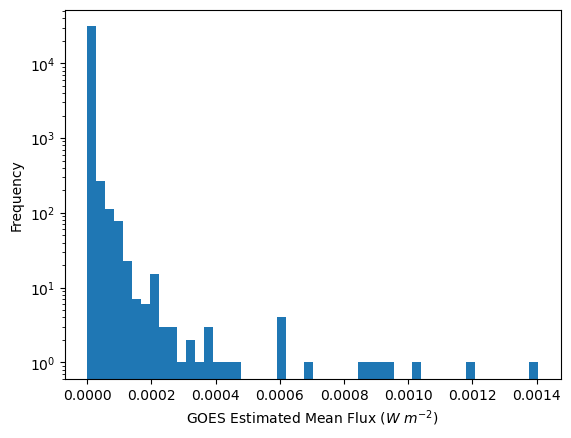

In [20]:
#size distribution - how rare are bigger flares?
flares['goes_estimated_mean_flux'].plot(kind='hist', logy=True, bins=50)
plt.xlabel('GOES Estimated Mean Flux ($W$ $m^{-2}$)')

In [12]:
#quantitative analysis?



In [13]:
#how many flares not visible from earth
not_earth_vis = flares[flares['visible_from_earth']==False]
not_earth_vis
#14949 flares(~half)

,start_UTC,end_UTC,peak_UTC,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,...,flare_id,sidelobes_ratio,goes_estimated_min_class,goes_estimated_max_class,goes_estimated_mean_class,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux,error_with_imaging,cpd_filename
16,2021-03-18T14:51:39.337,2021-03-18T14:58:55.337,2021-03-18 14:53:07.337,5375,335,99,927,543,271.0,53.0,...,2103181453,0.771060,B10,C2,C1,1.000000e-06,2.000000e-06,1.000000e-06,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2021031...
17,2021-03-19T14:01:39.177,2021-03-19T14:21:03.183,2021-03-19 14:05:31.178,1215,99,91,927,543,271.0,53.0,...,2103191405,0.754688,B5,B8,B6,5.000000e-07,8.000000e-07,6.000000e-07,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2021031...
18,2021-03-19T18:34:35.205,2021-03-19T18:53:51.109,2021-03-19 18:42:43.108,2687,183,99,927,543,271.0,53.0,...,2103191842,0.760059,B7,C1,B10,7.000000e-07,1.000000e-06,1.000000e-06,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2021031...
19,2021-03-20T09:04:39.093,2021-03-20T09:12:19.094,2021-03-20 09:06:39.093,1087,123,91,927,543,271.0,49.0,...,2103200906,0.770594,B4,B8,B6,4.000000e-07,8.000000e-07,6.000000e-07,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2021032...
20,2021-03-20T12:03:31.111,2021-03-20T12:29:11.114,2021-03-20 12:14:59.112,1727,151,91,927,543,271.0,49.0,...,2103201214,0.766514,B6,C1,B8,6.000000e-07,1.000000e-06,8.000000e-07,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2021032...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31191,2025-12-15T17:23:04.940,2025-12-15T17:36:44.941,2025-12-15 17:25:20.940,19455,2175,1215,927,335,303.0,41.0,...,2512151725,0.731880,C3,C7,C4,2.877831e-06,7.228153e-06,4.494576e-06,False,pixel_data/solo_L1_stix-sci-xray-cpd_20251215T...
31386,2025-12-31T19:39:08.633,2025-12-31T19:58:36.635,2025-12-31 19:40:44.633,3455,863,495,671,335,303.0,41.0,...,2512311940,0.761708,B10,C2,C1,9.802311e-07,2.095161e-06,1.412262e-06,False,pixel_data/solo_L1_stix-sci-xray-cpd_20251231T...
31406,2026-01-01T21:45:00.808,2026-01-01T21:57:08.810,2026-01-01 21:48:08.809,4863,463,199,671,335,303.0,41.0,...,2601012148,0.770536,C1,C3,C2,1.180247e-06,2.600448e-06,1.726445e-06,False,pixel_data/solo_L1_stix-sci-xray-cpd_20260101T...
31411,2026-01-02T02:45:08.842,2026-01-02T03:39:44.848,2026-01-02 02:53:08.843,31743,4351,1343,863,335,303.0,41.0,...,2601020253,0.756223,C4,C10,C6,3.672241e-06,9.528046e-06,5.829213e-06,False,pixel_data/solo_L1_stix-sci-xray-cpd_20260102T...


<Axes: ylabel='Frequency'>

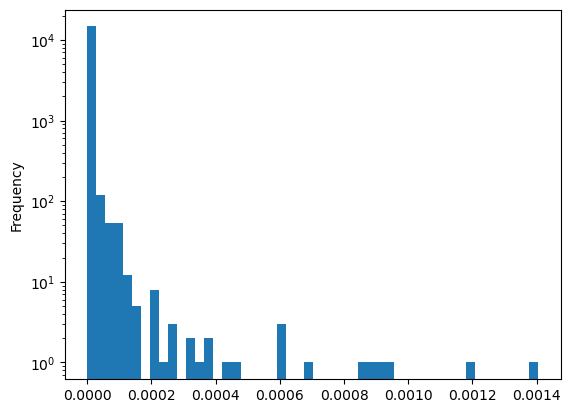

In [15]:
#is this useful? is there a better/more quantitive way to analyse? what defines a 'large' flare - by goes class?
not_earth_vis['goes_estimated_mean_flux'].plot(kind='hist', logy=True, bins=50)